In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
from pathlib import Path
import pandas as pd
from typing import List, Dict
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from functools import lru_cache


from rdkit import Chem
from rdkit.Chem import Descriptors

from prob.interactions.interaction_data import load_ident_activity_mapping
from prob.prob_plots import plot_dist_with_log, plot_transformation_mapping
from prob.paths_and_io import get_project_root, get_data_dir

# Paths

In [2]:
_ROOT = get_project_root()
print(f"Project root: {_ROOT}")
_DATA_DIR = get_data_dir(prob=False)
print(f"Data directory: {_DATA_DIR}")

interactions_dir  = _DATA_DIR / "plip_kinodata3d" / "processed"
mws_dir          = _DATA_DIR / "probing/helpers/mw"
intr_scores_dir   = _DATA_DIR / "probing/helpers/intr_scores"
targets_dir       = _DATA_DIR / "probing/targets"
figures_dir       = targets_dir / "figures"

Project root: /home/fatemeh/thesis/kinodata-3D-affinity-prediction
Data directory: /home/fatemeh/thesis/kinodata-3D-affinity-prediction/data


# Loading Data

In [36]:
interaction_names = ["halogen_bonds", "hydrogen_bonds", "hydrophobic_interactions", "pi_stacking", "salt_bridges"]


mapping = load_ident_activity_mapping()

# halogen_bonds_df = pd.read_csv(interactions_dir / "halogen_bonds.csv")
hydrogen_bonds_df = pd.read_csv(interactions_dir / "hydrogen_bonds.csv")
# hydrophobic_interactions_df = pd.read_csv(interactions_dir / "hydrophobic_interactions.csv")
# pi_stacking_df = pd.read_csv(interactions_dir / "pi_stacking.csv")
# salt_bridges_df = pd.read_csv(interactions_dir / "salt_bridges.csv")

# # interactions = [pd.read_csv(interactions_dir / f) for f in interaction_files]
# interactions_dfs = [halogen_bonds_df,
#                 hydrogen_bonds_df,
#                 hydrophobic_interactions_df,
#                 pi_stacking_df,
#                 salt_bridges_df]

### Continuous Intercation Score

The final score will be calculated as:
$$
\displaystyle\sum_{\text{residues}}{\text{residue attribution score} × \frac{\displaystyle\sum_{\text{bonds}}{\text{bond score}}}{\text{total number of bonds the ligand CAN form}}}
$$

Instead of using "the total numbers of bonds a molecule can form", I'll be using **MW** as a proxy. <br>
The reason for that is to find a standard weight (after pre-processing) to use for all type of bonds later on, rather than having to calculate this coefficient for each bond separately. MW is considered as an acceptable proxy, because the bigger the molecule, it is more likely to form more bonds.


The residue attribution scores 

### Discrete Interaction Score

This would be just the total number of interactions, factored by $MW^{-1}$

$MW$ is to account for the total number of bonds a molecule can form. Because the bigger the molecule, the more the number of bonds it can have

# MW
Statistical Analysis and Normalizations in mw notebook

In [4]:
mws = pd.read_csv(mws_dir / "mws.csv")
mws.head(2)

,smiles,ident,y_processed,activity_id,mw,mw_exp
0,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,0,5.148742,32335,370.456,1.924723
1,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1CCC...,17,6.000000,40693,386.455,1.965846


# Bond Score

## H-bonds
What PLIP does:
- Donor–acceptor distance $d_{DA}$ is $≤ 4.1 Å$ `(HBOND_DIST_MAX = 4.1)`
- Donor angle $∠(D−H⋯A)$ is $≥ 100°$ `(HBOND_DON_ANGLE_MIN = 100)`
- If the same groups already form a salt bridge, PLIP removes the overlapping hydrogen bond(s) (to avoid double-reporting)
- A donor is restricted to one H-bond; if multiple acceptors are possible, PLIP keeps the one whose $∠(D−H⋯A)$ is closest to $180°$. Acceptors can still participate in multiple bonds (bifurcated cases).

Let's define:

$\colorbox{orange}{This is the old version and it's wrong!}$

**Q**: a quality score that does not change too abruptly near the geometric thresholds, using a smooth logistic formulation to do this and to keep it in $[0,1]$:
$$
s_\theta = \sigma\!\left(\frac{d_{\max} - d}{\lambda_d}\right) \text{, and } s_d = \sigma\!\left(\frac{\theta - \theta_{\min}}{\lambda_\theta}\right)
$$
$$ 
Q = s_\theta \cdot s_d
$$

where the logistic (sigmoid) function is defined as:
$$ \sigma(x) = \frac{1}{1 + e^{-x}} $$

**Parameters:**

- $ d $: donor–acceptor distance (Å)  
- $ \theta $: donor–acceptor angle (degrees)  
- $ d_{\max} $: maximum distance cutoff (e.g. 4.1 Å in PLIP)  
- $ \theta_{\min} $: minimum angle cutoff (e.g. 100° in PLIP)  
- $ \lambda_d $: controls how fast the distance contribution ramps  
  (here **0.2–0.4 Å**)  
- $ \lambda_\theta $: controls angular softness  
  (here **5–15°**)  

The resulting score $Q \in (0,1)$, with higher values corresponding to shorter and more linear hydrogen bonds.

$\colorbox{yellowgreen}{The new version:}$

The relationship between the strength of the bond and angle and distance is so:
The stronger the bond, when:
- The more the angle is close to 180
- The less the distance


**So, we can say:**
$$
Q \propto \frac{\cos(∠(D−H⋯A))}{d_{DA}}  
$$

In [37]:
hydrogen_bonds_df.head()

,RESNR,RESTYPE,RESCHAIN,RESNR_LIG,RESTYPE_LIG,RESCHAIN_LIG,SIDECHAIN,DIST_H-A,DIST_D-A,DON_ANGLE,PROTISDON,DONORIDX,DONORTYPE,ACCEPTORIDX,ACCEPTORTYPE,LIGCOO,PROTCOO,activity_id
0,48,LEU,A,1,UNL,Z,False,1.79,2.69,151.89,False,1455,Npl,789,O2,"(-1.477, 18.513, 44.666)","(-3.405, 19.71, 46.118)",23227035
1,48,LEU,A,1,UNL,Z,False,1.92,2.90,162.57,True,784,Nam,1450,Nar,"(-0.942, 20.548, 43.637)","(-2.308, 22.328, 45.472)",23227035
2,52,SER,A,1,UNL,Z,False,2.03,2.96,151.87,True,845,Nam,1456,O2,"(-3.751, 12.62, 44.282)","(-4.813, 14.725, 42.494)",23227035
3,45,THR,A,1,UNL,Z,True,1.67,2.53,146.08,True,735,O3,1434,O2,"(1.909, 21.593, 40.698)","(3.132, 23.547, 41.736)",2111945
4,48,MET,A,1,UNL,Z,False,2.07,2.78,127.30,False,1432,Npl,782,O2,"(-1.082, 18.606, 45.341)","(-3.599, 19.474, 46.129)",2111945


- The column to use as $d$ is `DIST_D-A` $\rightarrow$ do I wanna incorporate `DIST_H-A` too? How? A weighted sum maybe?
- The column to use as $\theta$ is `DON_ANGLE`

In [30]:
save_dir = intr_scores_dir
save_dir

PosixPath('/home/fatemeh/thesis/kinodata-3D-affinity-prediction/data/probing/helpers/intr_scores')

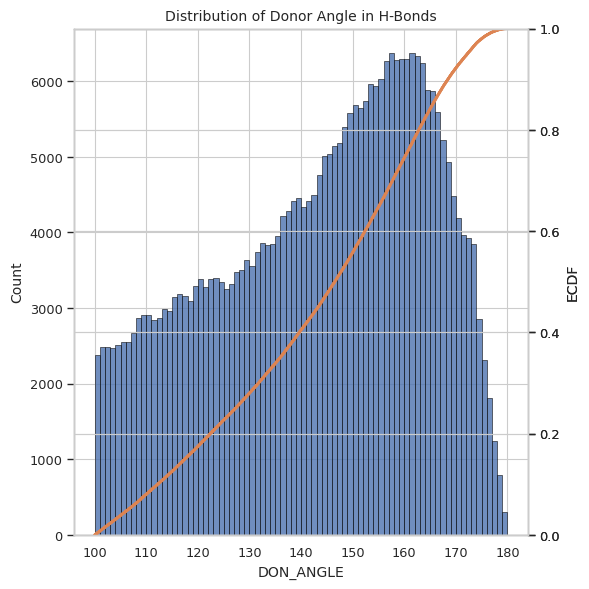

In [7]:
plot_dist_with_log(hydrogen_bonds_df, "DON_ANGLE", title = "Distribution of Donor Angle in H-Bonds", show_ecdf=True, save_path=save_dir / "donor_angle_distribution.png", show_log_y=False)

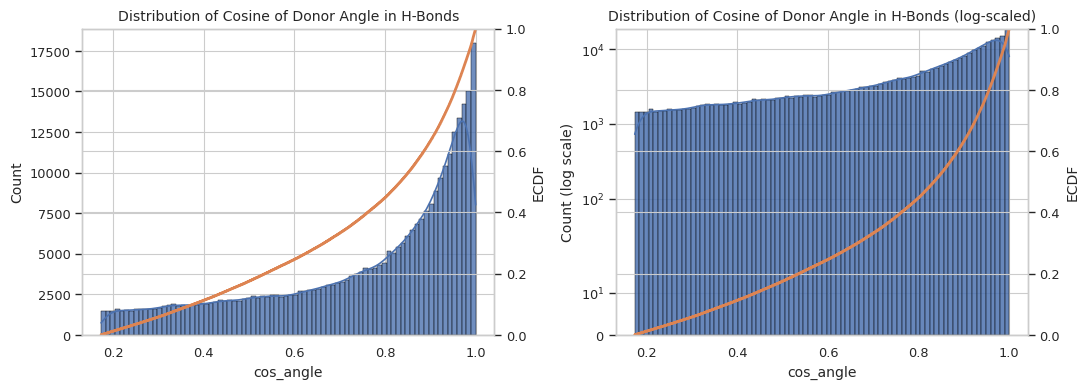

count    322499.000000
mean          0.752999
std           0.227277
min           0.173648
25%           0.605711
50%           0.834271
75%           0.941412
max           1.000000
Name: cos_angle, dtype: float64


In [38]:
# calculate cosine of donor angle for hydrogen bonds (we take the negative cosine to have a direct relationship with bond strength)
hydrogen_bonds_df["cos_angle"] = -np.cos(
    np.deg2rad(hydrogen_bonds_df["DON_ANGLE"])
)

plot_dist_with_log(hydrogen_bonds_df, col = "cos_angle", title = "Distribution of Cosine of Donor Angle in H-Bonds", kde=True, show_ecdf=True, )
                    # save_path=save_dir/"cos_angle_dist_hbond.png")
print(hydrogen_bonds_df["cos_angle"].describe())

In [5]:
# Defaults
D_MAX = 4.1        # Å based on PLIP documentation
THETA_MIN = 100.0  # degrees
lam_theta_min = 90.0  # degrees
lam_theta_max = 150.0  # degrees
lam_d_min = 2.4  # Å
lam_d_max = 4.4  # Å 

### Making a new df that has the scores, and join that to the bond df:

In [6]:
# DEPRECATED: These parameters were used in an earlier version of the code, but have since been updated. They are kept here for reference, but should not be used in the current implementation.
lam_d = 0.4  # Å
lam_theta = 15  # degrees

In [19]:
hydrogen_bonds_df["DIST_D-A"].mode()

0    2.99
Name: DIST_D-A, dtype: float64

w = -0.546 Å
d_mid = 1.700 Å


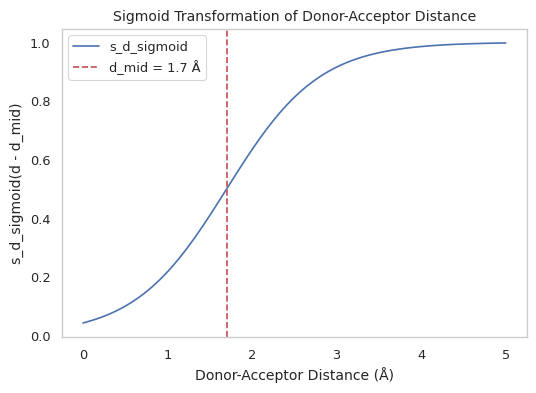

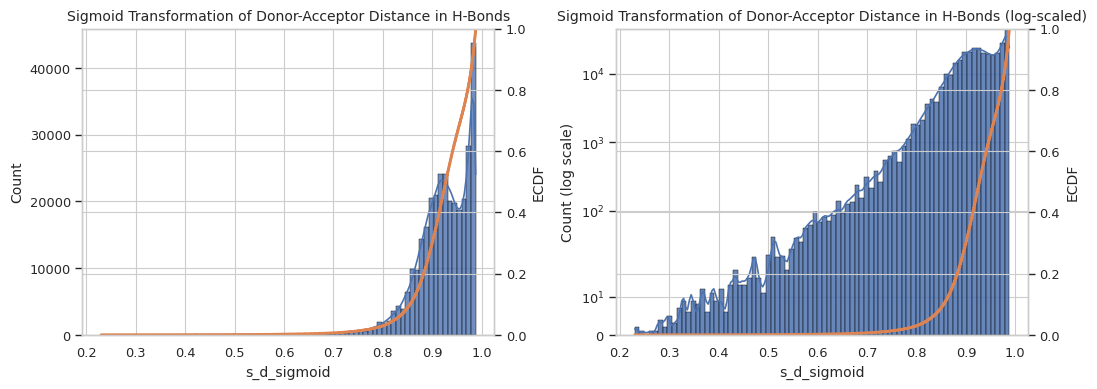

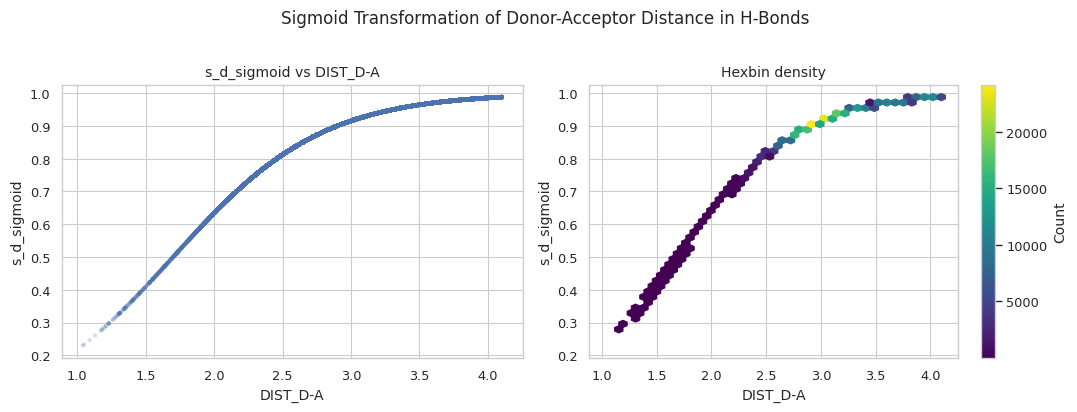

In [39]:
# s(2.9 Å) = 0.9 (near-ideal N/O···N/O) and s(4.1 Å) = 0.1 (PLIP's HBOND_DIST_MAX).
d_mod = 2.9
p_mod = 0.9
d_max = 4.1
p_max = 0.5

logit = lambda p: np.log(p / (1 - p))
w  = (d_max - d_mod) / (logit(p_max) - logit(p_mod))
print(f"w = {w:.3f} Å")
d_mid = d_mod + w*logit(p_mod)
print(f"d_mid = {d_mid:.3f} Å")

# s_d_hyperbolictan = lambda d: np.tanh((d - d_mid) / w)
s_d_sigmoid = lambda d: 1 / (1 + np.exp((d - d_mid) / w))

# plot the sigmoid itself and put a dot where d_mid and w are
d_values = np.linspace(0, 5, 100)
plt.figure(figsize=(6, 4))
plt.plot(d_values, s_d_sigmoid(d_values), label="s_d_sigmoid")
plt.xlabel("Donor-Acceptor Distance (Å)")
plt.ylabel("s_d_sigmoid(d - d_mid)")
plt.title("Sigmoid Transformation of Donor-Acceptor Distance")
plt.axvline(d_mid, color='r', linestyle='--', label=f"d_mid = {d_mid} Å")
plt.legend()
plt.grid()
plt.savefig(save_dir/"sigmoid_da_dist_hbond.png", dpi=300)

d = hydrogen_bonds_df["DIST_D-A"].to_numpy(dtype=float)
hydrogen_bonds_df["s_d_sigmoid"] = s_d_sigmoid(d)

plot_dist_with_log(hydrogen_bonds_df, col = "s_d_sigmoid", title = "Sigmoid Transformation of Donor-Acceptor Distance in H-Bonds", kde=True, show_ecdf=True,
                    save_path=save_dir/"sigmoid_da_dist_hbond.png")

plot_transformation_mapping(
    hydrogen_bonds_df,
    x_col = "DIST_D-A",
    y_col = "s_d_sigmoid", 
    add_binned_trend=False,
    kde_contour=False,
    title = "Sigmoid Transformation of Donor-Acceptor Distance in H-Bonds",
    save_path=save_dir/"sigmoid_da_dist_hbond_mapping.png"
    )

In [54]:
hydrogen_bonds_df["bond_score_sigmoid"] = (
    round(hydrogen_bonds_df["cos_angle"] * hydrogen_bonds_df["s_d_sigmoid"], 3)
)

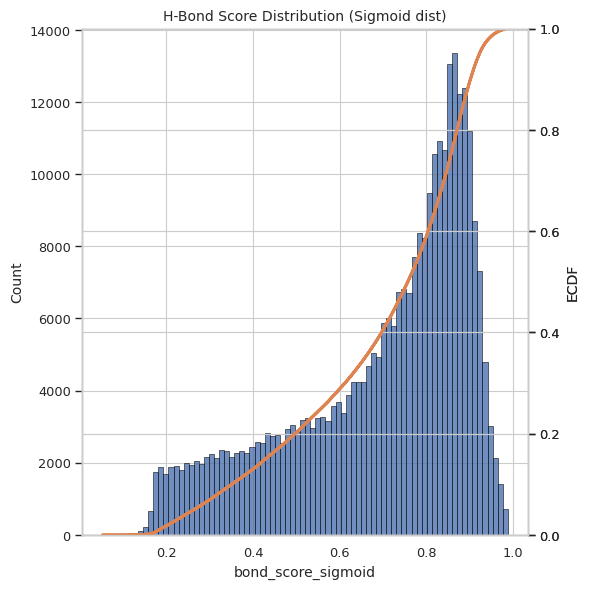

In [55]:
hydrogen_bonds_df["bond_score_sigmoid"].describe()

plot_dist_with_log(hydrogen_bonds_df, col="bond_score_sigmoid", 
                   title="H-Bond Score Distribution (Sigmoid dist)", show_ecdf=True, show_log_y=False, 
                   save_path=save_dir/"hb_score_sigmoid_dist_no_mw.png")

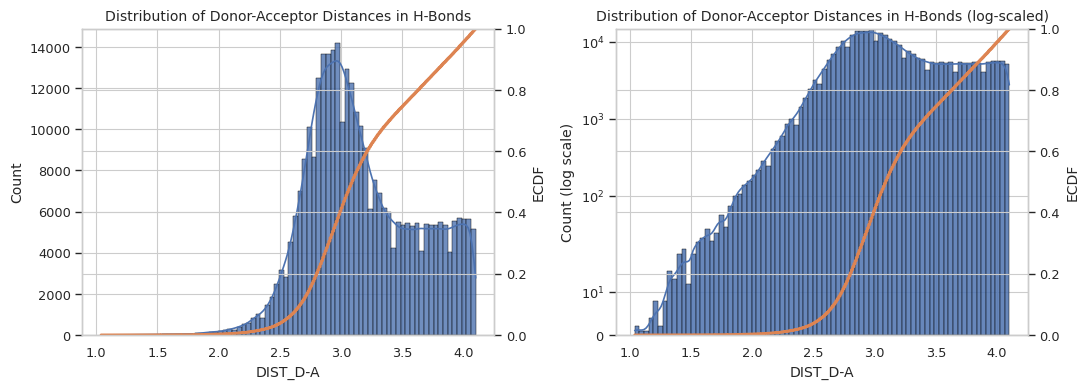

Mode: 2.99


count    322499.000000
mean          3.176407
std           0.448455
min           1.040000
25%           2.850000
50%           3.090000
75%           3.510000
max           4.100000
Name: DIST_D-A, dtype: float64

In [8]:
plot_dist_with_log(hydrogen_bonds_df, col = "DIST_D-A", title = "Distribution of Donor-Acceptor Distances in H-Bonds", kde=True, show_ecdf=True, 
                    save_path=save_dir/"d_a_dist_hbond.png")
print(f"Mode: {hydrogen_bonds_df['DIST_D-A'].mode()[0]}")
hydrogen_bonds_df['DIST_D-A'].describe()

$\colorbox{yellow}{Thoughts on this: }$
Maybe it's better to penalize both tails, and assign best score to a ideal middle distance.

This can be modeled with a Gaussian, peaked around an ideal distance.

$$
s_d(d) = \exp(- \frac{(d-d^*)^2}{2\sigma^2})
$$

So the score would be 1 at $d=d^*$

The $\sigma$ would control the speed of the penalization. To pick $\sigma$, <br>
We choose:
- ideal donor–acceptor distance: $ d^* = 2.9\ \text{Å} $
- desired score at $ d = 4.0\ \text{Å} $: $ s_d(4.0) = 0.1 $

Substituting into the equation:

$$
0.1 = \exp\!\left(-\frac{(4.0 - 2.9)^2}{2\sigma^2}\right)
$$

Taking the natural logarithm:

$$
\ln(0.1) = -\frac{1.1^2}{2\sigma^2}
$$

Solving for \( \sigma \):

$$
\sigma^2 = \frac{1.1^2}{-2\ln(0.1)}
$$

$$
\sigma = \frac{1.1}{\sqrt{-2\ln(0.1)}} \approx 0.51\ \text{Å}
$$

Thus, choosing $ \sigma \approx 0.5\ \text{Å} $ yields a chemically reasonable distance score where
donor–acceptor distances near the cutoff ($\sim 4.0\ \text{Å}$) are assigned low but nonzero quality.


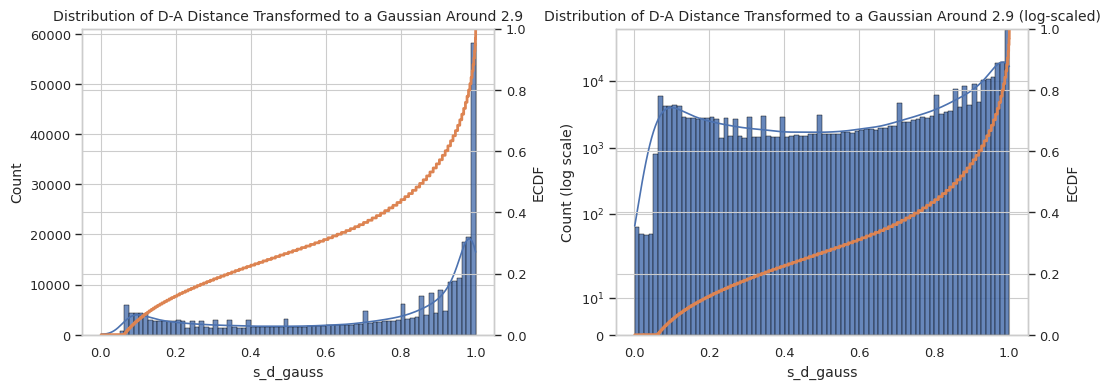

count    322499.000000
mean          0.709237
std           0.314231
min           0.001293
25%           0.455031
50%           0.860096
75%           0.972698
max           1.000000
Name: s_d_gauss, dtype: float64


In [11]:
# d_star = hydrogen_bonds_df["DIST_D-A"].mode()[0]
d_star = 2.9
sigma = 0.51
score_min = 1.0   # tail floor (set >0)
score_max = 10.0  # ideal-distance score

d = hydrogen_bonds_df["DIST_D-A"].to_numpy(dtype=float)

hydrogen_bonds_df["s_d_gauss"] = np.exp(-((d - d_star) ** 2) / (2 * sigma ** 2))

plot_dist_with_log(hydrogen_bonds_df, col = "s_d_gauss", title = "Distribution of D-A Distance Transformed to a Gaussian Around 2.9"
                   , kde=True, show_ecdf=True,
                   save_path = save_dir/"s_d_gauss_dist_hbond.png")
print(hydrogen_bonds_df["s_d_gauss"].describe())


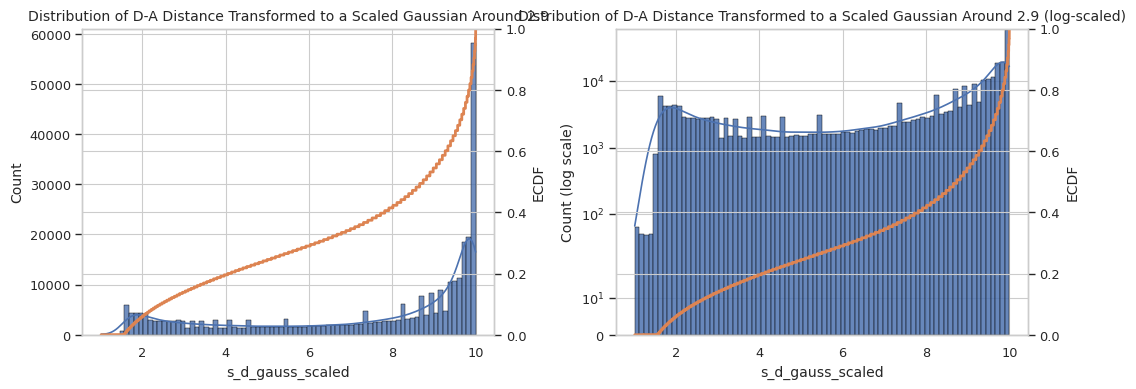

count    322499.000000
mean          7.383130
std           2.828076
min           1.011640
25%           5.095280
50%           8.740864
75%           9.754282
max          10.000000
Name: s_d_gauss_scaled, dtype: float64

In [13]:
hydrogen_bonds_df["s_d_gauss_scaled"] = score_min + (score_max - score_min) * hydrogen_bonds_df["s_d_gauss"]
plot_dist_with_log(hydrogen_bonds_df, col = "s_d_gauss_scaled", title = "Distribution of D-A Distance Transformed to a Scaled Gaussian Around 2.9"
                   , kde=True, show_ecdf=True,)
hydrogen_bonds_df["s_d_gauss_scaled"].describe()

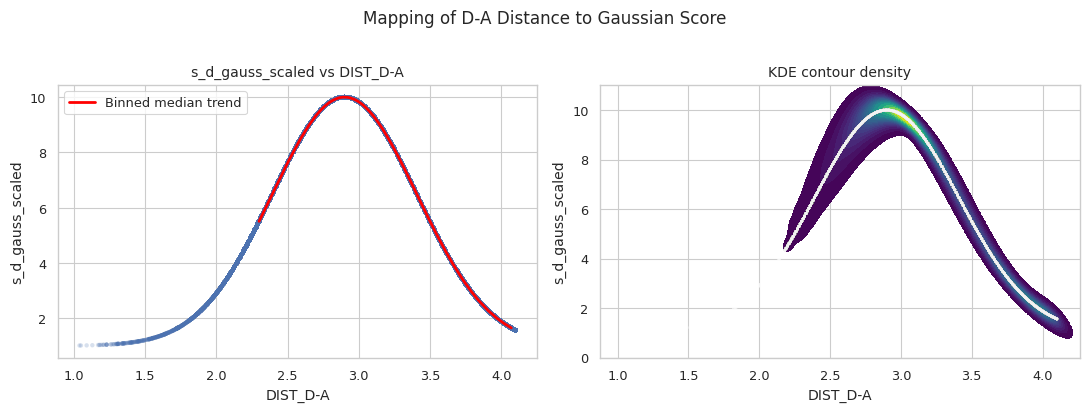

In [24]:
from prob.prob_plots import plot_transformation_mapping



plot_transformation_mapping(hydrogen_bonds_df, x_col = "DIST_D-A", y_col="s_d_gauss_scaled", title = "Mapping of D-A Distance to Gaussian Score",
                            save_path=save_dir/"d_a_to_gaussian.png")

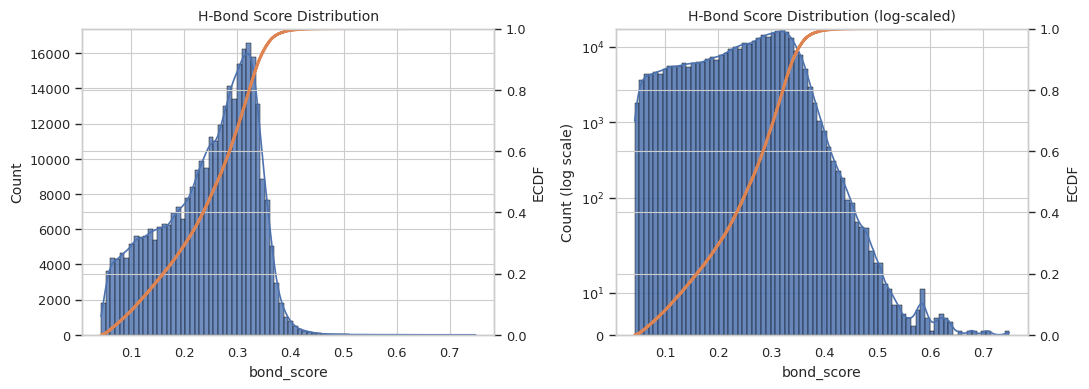

No Gaussian: count    322499.000000
mean          0.244523
std           0.086196
min           0.043000
25%           0.183000
50%           0.262000
75%           0.314000
max           0.749000
Name: bond_score, dtype: float64


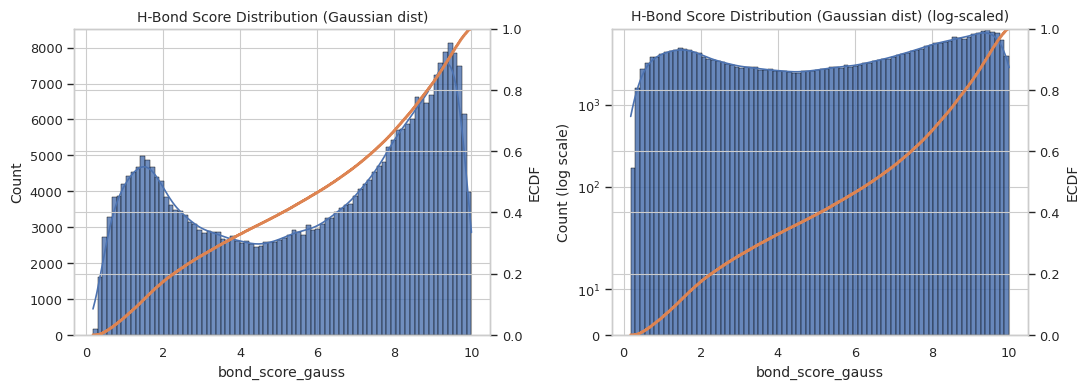

With Gaussian: count    322499.000000
mean          5.798683
std           3.009709
min           0.185000
25%           2.887000
50%           6.443000
75%           8.564000
max          10.000000
Name: bond_score_gauss, dtype: float64


In [14]:
# Old score
# hydrogen_bonds_df["bond_score"] = (round(s_d(d = hydrogen_bonds_df["DIST_D-A"], lam_d = lam_d) *
#                                   s_theta(theta = hydrogen_bonds_df["DON_ANGLE"], lam_theta=lam_theta), 3))

# New score

hydrogen_bonds_df["bond_score"] = (round(hydrogen_bonds_df["cos_angle"] / hydrogen_bonds_df["DIST_D-A"], 3))
hydrogen_bonds_df["bond_score_gauss"] = (round(hydrogen_bonds_df["cos_angle"] * hydrogen_bonds_df["s_d_gauss_scaled"], 3))
# hydrogen_bonds_df[["DIST_D-A", "DON_ANGLE", "bond_score"]].head(10)
plot_dist_with_log(hydrogen_bonds_df, col = "bond_score", title="H-Bond Score Distribution", kde=True, show_ecdf=True, 
                    save_path = save_dir/"hbond_score_dist.png")
print(f"No Gaussian: {hydrogen_bonds_df['bond_score'].describe()}")


plot_dist_with_log(hydrogen_bonds_df, col = "bond_score_gauss", title="H-Bond Score Distribution (Gaussian dist)", kde=True, show_ecdf=True, 
                    save_path = save_dir/"hbond_score_gauss_dist.png")
print(f"With Gaussian: {hydrogen_bonds_df['bond_score_gauss'].describe()}")

## Sigmoid Distance Scoring (Alternative Variant)

In [ ]:
# Sigmoid distance scoring parameters
# Uses logistic (sigmoid) function: sigma(x) = 1 / (1 + exp(-x))
# Applied to normalized distance: s_d_sigmoid(d) = sigma((d_max - d) / lam_d)

LAM_D_SIGMOID = 0.4   # Å, controls how fast distance contribution ramps
LAM_THETA_SIGMOID = 15  # degrees, controls angular softness
D_MAX_SIGMOID = 4.1   # Å, maximum distance cutoff

# Helper function: sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Calculate sigmoid-based distance score
d = hydrogen_bonds_df["DIST_D-A"].to_numpy(dtype=float)
hydrogen_bonds_df["s_d_sigmoid"] = sigmoid((D_MAX_SIGMOID - d) / LAM_D_SIGMOID)

plot_dist_with_log(hydrogen_bonds_df, col="s_d_sigmoid", 
                   title="Distribution of Sigmoid-Scaled D-A Distance",
                   kde=True, show_ecdf=True,
                   save_path=save_dir/"s_d_sigmoid_dist_hbond.png")
print(hydrogen_bonds_df["s_d_sigmoid"].describe())

In [ ]:
# Create bond score using sigmoid distance (same angle component as Gaussian version)
hydrogen_bonds_df["bond_score_sigmoid"] = (
    round(hydrogen_bonds_df["cos_angle"] * hydrogen_bonds_df["s_d_sigmoid"], 3)
)

In [ ]:


plot_dist_with_log(hydrogen_bonds_df, col="bond_score_sigmoid", 
                   title="H-Bond Score Distribution (Sigmoid dist)", 
                   kde=True, show_ecdf=True, 
                   save_path=save_dir/"hbond_score_sigmoid_dist.png")
print(f"With Sigmoid: {hydrogen_bonds_df['bond_score_sigmoid'].describe()}")

# Side-by-side comparison
plot_transformation_mapping(hydrogen_bonds_df, x_col="DIST_D-A", y_col="s_d_sigmoid", 
                            title="Mapping of D-A Distance to Sigmoid Score",
                            save_path=save_dir/"d_a_to_sigmoid.png")

In [26]:
print(len(hydrogen_bonds_df))
hydrogen_bonds_df.head()

322499


,RESNR,RESTYPE,RESCHAIN,RESNR_LIG,RESTYPE_LIG,RESCHAIN_LIG,SIDECHAIN,DIST_H-A,DIST_D-A,DON_ANGLE,...,ACCEPTORIDX,ACCEPTORTYPE,LIGCOO,PROTCOO,activity_id,cos_angle,s_d_gauss,s_d_gauss_scaled,bond_score,bond_score_gauss
0,48,LEU,A,1,UNL,Z,False,1.79,2.69,151.89,...,789,O2,"(-1.477, 18.513, 44.666)","(-3.405, 19.71, 46.118)",23227035,0.882045,0.918719,9.268470,0.328,8.175
1,48,LEU,A,1,UNL,Z,False,1.92,2.90,162.57,...,1450,Nar,"(-0.942, 20.548, 43.637)","(-2.308, 22.328, 45.472)",23227035,0.954084,1.000000,10.000000,0.329,9.541
2,52,SER,A,1,UNL,Z,False,2.03,2.96,151.87,...,1456,O2,"(-3.751, 12.62, 44.282)","(-4.813, 14.725, 42.494)",23227035,0.881880,0.993103,9.937931,0.298,8.764
3,45,THR,A,1,UNL,Z,True,1.67,2.53,146.08,...,1434,O2,"(1.909, 21.593, 40.698)","(3.132, 23.547, 41.736)",2111945,0.829818,0.768613,7.917515,0.328,6.570
4,48,MET,A,1,UNL,Z,False,2.07,2.78,127.30,...,782,O2,"(-1.082, 18.606, 45.341)","(-3.599, 19.474, 46.129)",2111945,0.605988,0.972698,9.754282,0.218,5.911


Sum over residues:

### Normalized MWs as weights

In [32]:
weights = (mapping.set_index("activity_id")["inv_mw_01"]).rename("mw_weight")
print(len(weights))
weights.describe()

KeyError: 'inv_mw_01'

In [41]:
hydrogen_bonds_df.head()

,RESNR,RESTYPE,RESCHAIN,RESNR_LIG,RESTYPE_LIG,RESCHAIN_LIG,SIDECHAIN,DIST_H-A,DIST_D-A,DON_ANGLE,...,ACCEPTORIDX,ACCEPTORTYPE,LIGCOO,PROTCOO,activity_id,s_d_gauss,cos_angle,bond_score,s_d_gauss_scaled,bond_score_gauss
0,48,LEU,A,1,UNL,Z,False,1.79,2.69,151.89,...,789,O2,"(-1.477, 18.513, 44.666)","(-3.405, 19.71, 46.118)",23227035,0.918719,0.882045,0.328,9.268470,8.175
1,48,LEU,A,1,UNL,Z,False,1.92,2.90,162.57,...,1450,Nar,"(-0.942, 20.548, 43.637)","(-2.308, 22.328, 45.472)",23227035,1.000000,0.954084,0.329,10.000000,9.541
2,52,SER,A,1,UNL,Z,False,2.03,2.96,151.87,...,1456,O2,"(-3.751, 12.62, 44.282)","(-4.813, 14.725, 42.494)",23227035,0.993103,0.881880,0.298,9.937931,8.764
3,45,THR,A,1,UNL,Z,True,1.67,2.53,146.08,...,1434,O2,"(1.909, 21.593, 40.698)","(3.132, 23.547, 41.736)",2111945,0.768613,0.829818,0.328,7.917515,6.570
4,48,MET,A,1,UNL,Z,False,2.07,2.78,127.30,...,782,O2,"(-1.082, 18.606, 45.341)","(-3.599, 19.474, 46.129)",2111945,0.972698,0.605988,0.218,9.754282,5.911


### The number of bonds per complex

113453


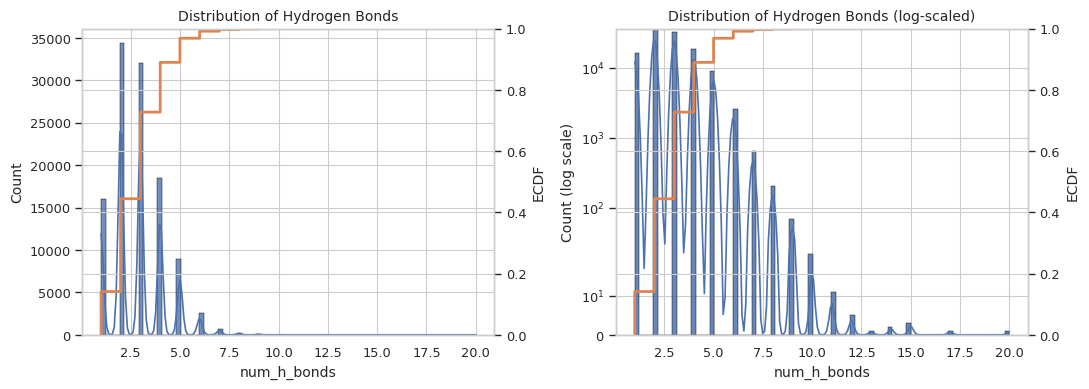

count    113453.000000
mean          2.842578
std           1.310509
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          20.000000
Name: num_h_bonds, dtype: float64


,activity_id,num_h_bonds,ident,y_processed
0,13302668,20,33827.0,5.148742
1,7808140,17,25008.0,6.425969
2,1097676,15,3102.0,8.585027
3,1090959,15,3069.0,8.136677
4,12688515,15,33006.0,4.853872


In [43]:
num_hydrogen_bonds = hydrogen_bonds_df['activity_id'].value_counts().reset_index(name='num_h_bonds')
# num_hydrogen_bonds = num_hydrogen_bonds.merge(mws, on='activity_id', how='right')
# num_hydrogen_bonds['weighted_num_hbs'] = (num_hydrogen_bonds['num_h_bonds'] * num_hydrogen_bonds['mw_weight'])
num_hydrogen_bonds = num_hydrogen_bonds.merge(mapping[['activity_id', 'ident', 'y_processed']], on='activity_id', how='left')

print(len(num_hydrogen_bonds))

plot_dist_with_log(num_hydrogen_bonds, col="num_h_bonds", title="Distribution of Hydrogen Bonds", kde=True, show_ecdf=True, save_path=save_dir/"num_h_bonds_dist.png")
print(num_hydrogen_bonds["num_h_bonds"].describe())

num_hydrogen_bonds.head()

### The weighted average score per complex

In [35]:
hydrogen_bonds_df.head(2)

,RESNR,RESTYPE,RESCHAIN,RESNR_LIG,RESTYPE_LIG,RESCHAIN_LIG,SIDECHAIN,DIST_H-A,DIST_D-A,DON_ANGLE,...,DONORIDX,DONORTYPE,ACCEPTORIDX,ACCEPTORTYPE,LIGCOO,PROTCOO,activity_id,sigmoid_DIST_D-A,hyperbolictan_DIST_D-A,cos_angle
0,48,LEU,A,1,UNL,Z,False,1.79,2.69,151.89,...,1455,Npl,789,O2,"(-1.477, 18.513, 44.666)","(-3.405, 19.71, 46.118)",23227035,0.859689,1.0,0.882045
1,48,LEU,A,1,UNL,Z,False,1.92,2.90,162.57,...,784,Nam,1450,Nar,"(-0.942, 20.548, 43.637)","(-2.308, 22.328, 45.472)",23227035,0.900000,1.0,0.954084


In [56]:
# bond_score_col = "bond_score_gauss"
bond_score_col = "bond_score_sigmoid"
# bond_score_col = "bond_score"

bond_scores = (
    hydrogen_bonds_df
    .groupby("activity_id", as_index=False)[bond_score_col]
    .sum()
)
bond_scores

,activity_id,bond_score_sigmoid
0,32335,0.409
1,32336,1.697
2,32680,2.746
3,32770,3.065
4,33033,1.438
...,...,...
113448,24970093,3.157
113449,24970094,3.105
113450,24970095,3.220
113451,24970104,3.199


In [57]:
bond_scores = bond_scores.merge(mws, on='activity_id', how='right').dropna(subset=[bond_score_col])
print(len(bond_scores))
bond_scores.head()

112559


,activity_id,bond_score_sigmoid,smiles,ident,y_processed,mw,mw_exp
0,32335,0.409,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,0,5.148742,370.456,1.924723
2,41979,1.693,c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1,20,5.565431,313.360,1.770198
3,51886,1.664,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1C[C...,44,6.568636,402.454,2.006126
4,443639,0.238,CC(C)(C)n1cc(-c2ccc(Oc3ccccc3)cc2)c2c(N)ncnc21,1221,5.640165,358.445,1.893264
5,447791,0.482,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)c(C(=O)[O-])n...,1232,5.007889,413.457,2.033364


In [ ]:
bond_scores['weighted_hb_score'] = (bond_scores[bond_score_col] / bond_scores['mw_exp'])
bond_scores.head()

,activity_id,sum_hb_score,smiles,ident,y_processed,mw,mw_exp,weighted_hb_score
0,32335,4.430,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,0,5.148742,370.456,1.924723,2.301629
2,41979,18.244,c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1,20,5.565431,313.360,1.770198,10.306193
3,51886,10.958,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1C[C...,44,6.568636,402.454,2.006126,5.462270
4,443639,0.772,CC(C)(C)n1cc(-c2ccc(Oc3ccccc3)cc2)c2c(N)ncnc21,1221,5.640165,358.445,1.893264,0.407761
5,447791,3.421,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)c(C(=O)[O-])n...,1232,5.007889,413.457,2.033364,1.682433


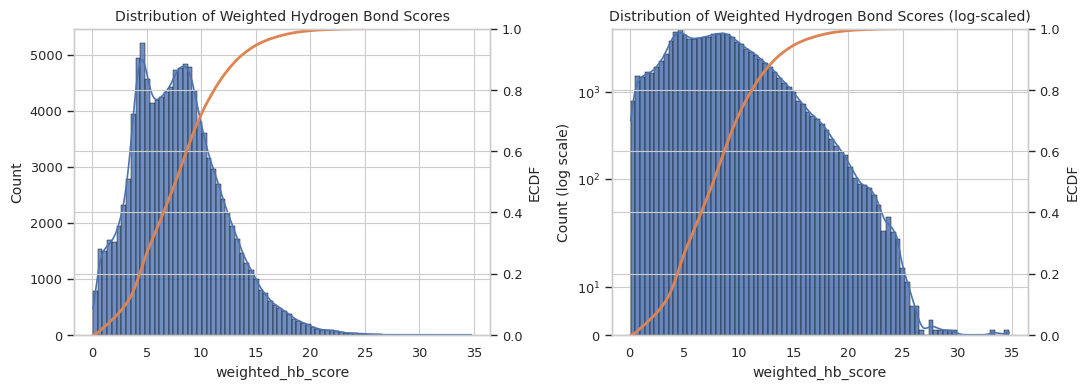

count    112559.000000
mean          7.950781
std           4.070592
min           0.090148
25%           4.849075
50%           7.657834
75%          10.419127
max          34.768153
Name: weighted_hb_score, dtype: float64


In [ ]:
col = "weighted_hb_score"
# col = "sum_hb_score"
plot_dist_with_log(bond_scores, col=col, title = "Distribution of Hydrogen Bond Scores", kde=True, show_ecdf=True, save_path=save_dir/"sum_hb_score_dist.png")
print(bond_scores[col].describe())

### Save Both Variants

Filter Outliers

In [58]:
# interactions = {
#     "weighted_hb_score": bond_scores,
#     "num_h_bonds": num_hydrogen_bonds
# }
bond_score_col = "bond_score_sigmoid"
interactions = {bond_score_col: bond_scores}
interactions

{'bond_score_sigmoid':         activity_id  bond_score_sigmoid  \
 0             32335               0.409   
 2             41979               1.693   
 3             51886               1.664   
 4            443639               0.238   
 5            447791               0.482   
 ...             ...                 ...   
 119515     24902990               1.628   
 119516     24902991               1.225   
 119519     24954009               3.421   
 119520     24958004               2.805   
 119521     24958232               3.291   
 
                                                    smiles   ident  \
 0             Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1       0   
 2                    c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1      20   
 3       Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1C[C...      44   
 4          CC(C)(C)n1cc(-c2ccc(Oc3ccccc3)cc2)c2c(N)ncnc21    1221   
 5       Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)c(C(=O)[O-])n...    1232   
 ...                        

In [59]:
from prob.paths_and_io import save_out_tensor


for intr_name, intr_df in interactions.items():
    # store it as a dict of ident:value
    interaction_dict = intr_df.set_index('ident')[intr_name].to_dict()
    save_out_tensor(interaction_dict, output_dir = _ROOT/"data/probing/targets", filename = f"{intr_name}.pt")

## Calculate Correlations

In [60]:
def compute_correlations(
    df: pd.DataFrame,
    bond_col: str,
    y_col: str = "y_processed",
) -> dict[str, float]:
    """Compute Pearson and Spearman correlations between number of bonds and affinity."""
    sub_df = df[[bond_col, y_col]].dropna()
    pearson = sub_df.corr(method="pearson").iloc[0, 1]
    spearman = sub_df.corr(method="spearman").iloc[0, 1]
    return {"pearson": pearson, "spearman": spearman}


def compute_bond_stats(
    df: pd.DataFrame,
    bond_col: str,
) -> dict[str, float]:
    """Compute basic statistics (mean, median, variance) for bond counts."""
    sub_series = df[bond_col].dropna()
    return {
        "mean": round(sub_series.mean(), 3),
        "median": round(sub_series.median(), 3),
        "variance": round(sub_series.var(), 3),
    }


def plot_scatter_with_regression(
    df: pd.DataFrame, bond_col: str, y_col: str = "y_processed",
    hue: str = None,
    dropna: bool = True,
    title: str = None,):
    """ Scatter plot with regression line. """
    data = df[[bond_col, y_col] + ([hue] if hue else [])]
    
    if dropna:
        data = data.dropna()

    plt.figure(figsize=(6, 5))
    sns.regplot(
        data=data,
        x=bond_col,
        y=y_col,
        scatter_kws={"alpha": 0.2, "s": 10},
        line_kws={"color": "red"},
    )

    if title:
        plt.title(title)
    else:
        plt.title(f"{y_col} vs {bond_col}")

    plt.tight_layout()
    plt.show()

In [61]:
from scipy.stats import linregress

def plot_scatter_with_regression(
    df: pd.DataFrame,
    bond_col: str,
    y_col: str = "y_processed",
    dropna: bool = True,
    title: str = None,
    subsample: int | None = 5000,
    use_hexbin: bool = True,
    save_dir: Path | None = None,
):
    data = df[[bond_col, y_col]]
    if dropna:
        data = data.dropna()

    # --- regression on FULL data ---
    res = linregress(data[bond_col], data[y_col])

    print(
        f"[Linear regression]\n"
        # f"slope     = {res.slope:.4f}\n"
        # f"intercept = {res.intercept:.4f}\n"
        # f"r         = {res.rvalue:.4f}\n"
        f"r^2       = {res.rvalue**2:.4f}\n"
        f"p-value   = {res.pvalue:.2e}\n"
    )

    # --- subsample for visualization ---
    if subsample is not None and len(data) > subsample:
        data_vis = data.sample(subsample, random_state=0)
    else:
        data_vis = data

    plt.figure(figsize=(6, 5))

    if use_hexbin:
        plt.hexbin(
            data_vis[bond_col],
            data_vis[y_col],
            gridsize=40,
            cmap="viridis",
        )
        plt.colorbar(label="count")

        # regression line
        x = np.linspace(data[bond_col].min(), data[bond_col].max(), 100)
        y = res.intercept + res.slope * x
        plt.plot(x, y, color="red", linewidth=2)

    else:
        sns.regplot(
            data=data_vis,
            x=bond_col,
            y=y_col,
            scatter_kws={"alpha": 0.3, "s": 20},
            line_kws={"color": "red"},
        )

    plt.xlabel(bond_col)
    plt.ylabel(y_col)

    if title:
        plt.title(title)
    else:
        plt.title(f"{y_col} vs {bond_col}")

    plt.tight_layout()
    plt.show()
    if save_dir is not None:
        plt.savefig(save_dir)

In [62]:
bond_scores.head()

,activity_id,bond_score_sigmoid,smiles,ident,y_processed,mw,mw_exp
0,32335,0.409,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,0,5.148742,370.456,1.924723
2,41979,1.693,c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1,20,5.565431,313.360,1.770198
3,51886,1.664,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1C[C...,44,6.568636,402.454,2.006126
4,443639,0.238,CC(C)(C)n1cc(-c2ccc(Oc3ccccc3)cc2)c2c(N)ncnc21,1221,5.640165,358.445,1.893264
5,447791,0.482,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)c(C(=O)[O-])n...,1232,5.007889,413.457,2.033364


In [34]:
_DATA_DIR

PosixPath('/home/fatemeh/thesis/kinodata-3D-affinity-prediction/data')

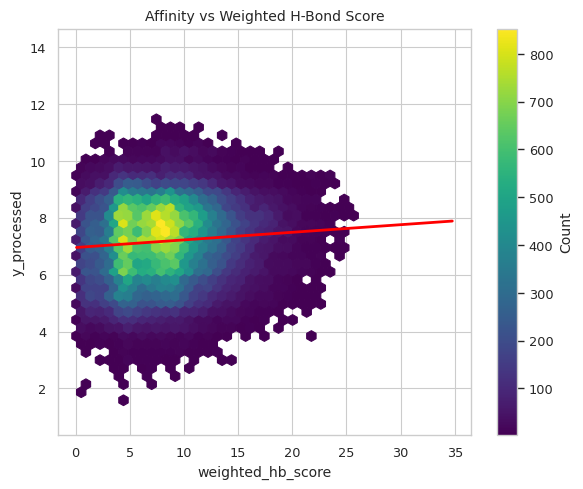

In [ ]:
from prob.prob_plots import scatter_affinity_vs_bonds

scatter_affinity_vs_bonds(bond_scores, bond_col="weighted_hb_score", title="Affinity vs Weighted H-Bond Score", save_path=figures_dir/"affinity_vs_weighted_hb_score.png")

In [ ]:
scatter_affinity_vs_bonds(num_hydrogen_bonds, bond_col="num_h_bonds", title="Affinity vs Number of H-Bonds", save_path=figures_dir/"affinity_vs_num_h_bonds.png")

NameError: name 'scatter_affinity_vs_bonds' is not defined


bond_score_sigmoid correlations: {'pearson': 0.13165502925564493, 'spearman': 0.1302409931070291}
stats: {'mean': 1.962, 'median': 1.806, 'variance': 0.835}
[Linear regression]
r^2       = 0.0173
p-value   = 0.00e+00



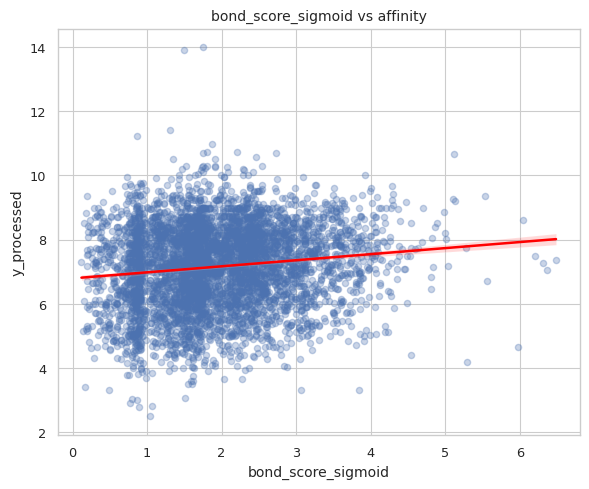

In [64]:
for intr_name, intr_df in interactions.items():
    corrs = compute_correlations(intr_df, bond_col=intr_name)
    print(f"\n{intr_name} correlations: {corrs}")
    print(f"stats: {compute_bond_stats(intr_df, bond_col=intr_name)}")
    plot_scatter_with_regression(
        intr_df,
        bond_col=intr_name,
        title=f"{intr_name} vs affinity",
        use_hexbin=False,
        # save_dir=figures_dir/f"scatter_{intr_name}_vs_affinity.png"
    )

# Hydrophobic interactions

In [47]:
hydrophobic_interactions_df = pd.read_csv(interactions_dir / "hydrophobic_interactions.csv")
hydrophobic_interactions_df.head()

,RESNR,RESTYPE,RESCHAIN,RESNR_LIG,RESTYPE_LIG,RESCHAIN_LIG,DIST,LIGCARBONIDX,PROTCARBONIDX,LIGCOO,PROTCOO,activity_id
0,3,LEU,A,1,UNL,Z,3.67,1429,50,"(-1.716, 16.737, 46.306)","(1.733, 16.043, 47.345)",23227035
1,11,VAL,A,1,UNL,Z,3.74,1433,150,"(1.081, 18.346, 40.738)","(4.321, 18.502, 42.597)",23227035
2,15,ALA,A,1,UNL,Z,3.97,1436,212,"(0.368, 20.526, 41.618)","(3.197, 22.165, 43.864)",23227035
3,36,VAL,A,1,UNL,Z,3.64,1448,579,"(1.026, 21.29, 40.525)","(-0.973, 24.295, 40.031)",23227035
4,47,TYR,A,1,UNL,Z,3.64,1429,777,"(-1.716, 16.737, 46.306)","(-0.036, 19.395, 48.146)",23227035


In [49]:
save_dir

PosixPath('/home/fatemeh/thesis/kinodata-3D-affinity-prediction/data/probing/helpers/intr_scores')

116478


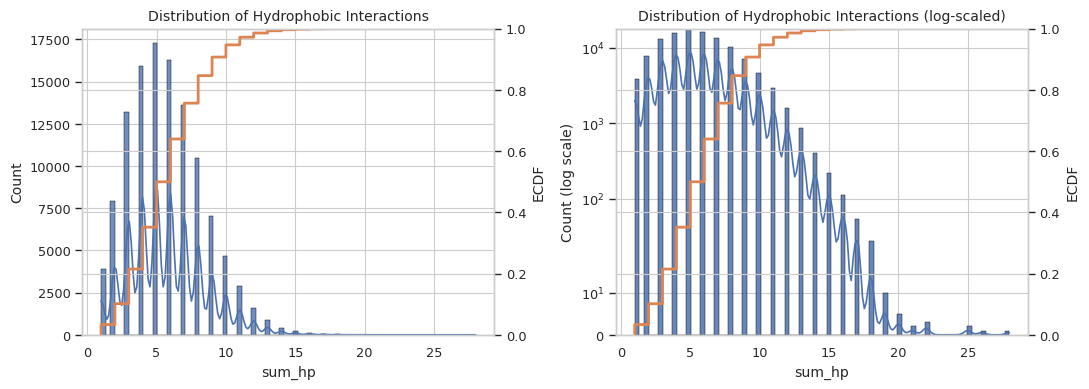

Hydrophobic interaction score stats:
count    116478.000000
mean          5.761045
std           2.706065
min           1.000000
25%           4.000000
50%           6.000000
75%           7.000000
max          28.000000
Name: sum_hp, dtype: float64


,activity_id,sum_hp,ident,y_processed
0,24708162,28,116268.0,8.000000
1,2044839,26,8619.0,4.640165
2,13302668,25,33827.0,5.148742
3,18201830,25,94517.0,7.950782
4,19071954,22,101669.0,5.158453


In [50]:
hydrophobic_intr_total = hydrophobic_interactions_df['activity_id'].value_counts().reset_index(name='sum_hp')
hydrophobic_intr_total = hydrophobic_intr_total.merge(mapping[['activity_id', 'ident', 'y_processed']], on='activity_id', how='left')

print(len(hydrophobic_intr_total))

plot_dist_with_log(hydrophobic_intr_total, col="sum_hp", title="Distribution of Hydrophobic Interactions", kde=True, show_ecdf=True, save_path=_DATA_DIR/"probing/targets/figures/hydrophobic_interactions_dist.png")

print(f"Hydrophobic interaction score stats:")
print(hydrophobic_intr_total["sum_hp"].describe())
hydrophobic_intr_total.head()


 sum_hp correlations: {'pearson': 0.03733411697029246, 'spearman': 0.03552944562515529}
stats: {'mean': 5.761, 'median': 6.0, 'variance': 7.323}
[Linear regression]
r^2       = 0.0014
p-value   = 6.19e-37



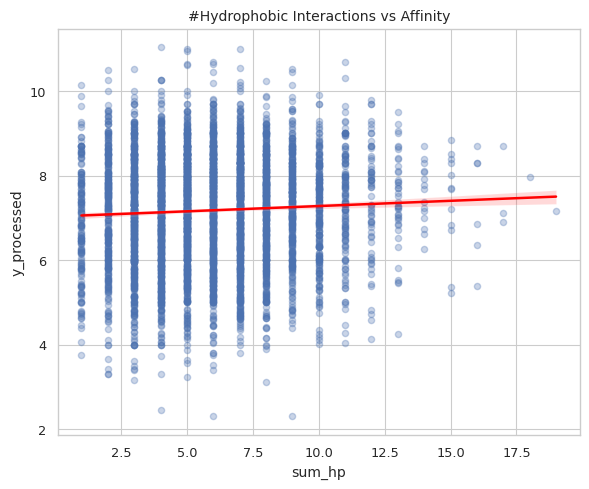

<Figure size 640x480 with 0 Axes>

In [ ]:
corrs = compute_correlations(hydrophobic_intr_total, bond_col="sum_hp")
print(f"\n sum_hp correlations: {corrs}")
print(f"stats: {compute_bond_stats(hydrophobic_intr_total, bond_col='sum_hp')}")
plot_scatter_with_regression(
    hydrophobic_intr_total,
    bond_col="sum_hp",
    title=f"#Hydrophobic Interactions vs Affinity",
    use_hexbin=False,
    save_dir=figures_dir/"scatter_sum_hp_vs_affinity.png"
)

In [ ]:
hp_dict = hydrophobic_intr_total.set_index('ident')["sum_hp"].to_dict()
save_out_tensor(hp_dict, output_dir = targets_dir, filename = f"sum_hp.pt")

PosixPath('/home/fatemeh/thesis/kinodata-3D-affinity-prediction/data/probing/targets/sum_hp.pt')